# 03 · Eficiencia de despliegue — Matryoshka (P6) y chunking (P4)

**Alcance:** trade-offs de **efectividad vs. latencia vs. memoria** al (a) truncar la
dimensión del embedding (P6) y (b) variar el tamaño y solapamiento de fragmento (P4), para
recomendar una configuración **eficiente para despliegue local** (**punto 4**).

## 1. Contexto y objetivos

La configuración de referencia (Híbrido + ontología) usa embeddings de 1024 dimensiones y un
documento por unidad de indexación. Dos palancas de eficiencia:

- **P6 · Matryoshka (MRL).** `jina-embeddings-v3` permite **truncar** el vector a `m` < 1024
  sin reentrenar (los primeros `m` componentes siguen siendo válidos), reduciendo memoria del
  índice y — a gran escala — latencia de búsqueda.
- **P4 · Chunking.** Partir cada documento en fragmentos con solapamiento puede ayudar cuando
  los documentos son largos; a la escala actual (reportes de ~65–180 palabras) esperamos poco
  efecto, pero dejamos la maquinaria lista y medida para la v2.

## 2. Preparación, datos y núcleo de recuperación

### Núcleo de recuperación (idéntico en todos los notebooks de la entrega)

Para que cada notebook sea **autónomo y reproducible**, se define aquí todo el código de recuperación y evaluación: librerías, carga de datos, métricas, índices (BM25 y denso), fusión RRF, detector de entidades, el motor de las cinco configuraciones y la estadística. No se importa nada de `experimentos/lib`.

In [1]:
# --- Librerías y utilidades base ---
import json, sys, time, math, re, unicodedata, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25})

# Localiza la raíz del proyecto y la carpeta de datos del experimento.
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
EXP = RAIZ / "experimentos"
cfg = yaml.safe_load((EXP / "config.yaml").read_text(encoding="utf-8"))
SEMILLA = cfg["evaluacion"]["semilla"]
np.random.seed(SEMILLA)
print("Encoder:", cfg["encoder"]["tipo"], "→", cfg["encoder"]["modelo_st"])
print("BM25:", cfg["bm25"], "| RRF k =", cfg["fusion"]["k_rrf"], "| realce λ =", cfg["realce"]["lambda"])

Encoder: sentence-transformer → jinaai/jina-embeddings-v3
BM25: {'k1': 1.5, 'b': 0.75} | RRF k = 60 | realce λ = 0.2


In [2]:
# --- Carga de datos ya construidos por el pipeline reproducible (make all) ---
# El corpus lo produce experimentos/preprocess_corpus.py; las consultas y juicios,
# experimentos/generar_consultas.py (protocolo known-item). Aquí solo se leen.
def cargar_jsonl(ruta):
    return [json.loads(l) for l in Path(ruta).read_text(encoding="utf-8").splitlines() if l.strip()]

docs      = cargar_jsonl(EXP / cfg["rutas"]["corpus"])
consultas = cargar_jsonl(EXP / cfg["rutas"]["consultas"])
qrels     = {r["id"]: r["relevancia"] for r in cargar_jsonl(EXP / cfg["rutas"]["qrels"])}
ontologia = yaml.safe_load((EXP / cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))

tiene_gold = lambda q: any(g > 0 for g in q.values())
con_gold = [c for c in consultas if tiene_gold(qrels.get(c["id"], {}))]
estratos = sorted({c["estrato"] for c in consultas})
print(f"{len(docs)} documentos | {len(consultas)} consultas | {len(con_gold)} con gold")
print("Estratos:", {e: sum(1 for c in consultas if c['estrato']==e) for e in estratos})

17 documentos | 51 consultas | 40 con gold
Estratos: {'ambigua': 13, 'competencias': 11, 'documento_largo': 10, 'entidad_exacta': 17}


In [3]:
# --- Métricas de recuperación (nDCG, Recall, MRR, P@k, AP) con ganancia exponencial ---
def _grado(qrel, doc): return float(qrel.get(doc, 0.0))

def dcg(ranking, qrel, k):
    return sum((2.0**_grado(qrel, d) - 1.0) / math.log2(i + 1)
               for i, d in enumerate(ranking[:k], 1) if _grado(qrel, d) > 0)

def ndcg(ranking, qrel, k):
    ideal = sorted((g for g in qrel.values() if g > 0), reverse=True)
    idcg = sum((2.0**g - 1.0) / math.log2(i + 1) for i, g in enumerate(ideal[:k], 1))
    return 0.0 if idcg == 0 else dcg(ranking, qrel, k) / idcg

def recall(ranking, qrel, k):
    rel = {d for d, g in qrel.items() if g > 0}
    return 0.0 if not rel else sum(1 for d in ranking[:k] if d in rel) / len(rel)

def mrr(ranking, qrel, k):
    for i, d in enumerate(ranking[:k], 1):
        if _grado(qrel, d) > 0: return 1.0 / i
    return 0.0

def precision(ranking, qrel, k):
    return 0.0 if k == 0 else sum(1 for d in ranking[:k] if _grado(qrel, d) > 0) / k

def average_precision(ranking, qrel, k):
    rel = {d for d, g in qrel.items() if g > 0}
    if not rel: return 0.0
    ac, s = 0, 0.0
    for i, d in enumerate(ranking[:k], 1):
        if d in rel: ac += 1; s += ac / i
    return s / min(len(rel), k)

def metricas_consulta(rank, qrel):
    return {"ndcg@10": ndcg(rank, qrel, 10), "mrr@10": mrr(rank, qrel, 10),
            "recall@100": recall(rank, qrel, 100), "p@10": precision(rank, qrel, 10),
            "ap@100": average_precision(rank, qrel, 100)}

# auto-test mínimo
assert ndcg(["a","b"], {"a":1.0}, 10) == 1.0 and mrr(["b","a"], {"a":1.0}, 10) == 0.5
print("Métricas listas (auto-test OK).")

Métricas listas (auto-test OK).


In [4]:
# --- Núcleo de recuperación: BM25, codificador denso, RRF, detector y motor ---
_STOP = {"el","la","los","las","un","una","unos","unas","de","del","a","ante","con","en","para",
         "por","que","y","o","u","se","su","sus","lo","al","es","son","como","mas","pero","sin",
         "sobre","entre","cada","ya","cuando","donde","cual","quien","cuanto","muy","este","esta","estos"}

def tokenizar_es(texto):
    "Minúsculas, sin tildes, sin puntuación ni stopwords."
    texto = unicodedata.normalize("NFKD", texto.lower())
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return [t for t in re.findall(r"[a-z0-9]+", texto) if t not in _STOP and len(t) > 1]

class BM25Index:
    "BM25 clásico desde cero, con analizador en español."
    def __init__(self, k1=1.5, b=0.75): self.k1, self.b = k1, b
    def indexar(self, ids, textos):
        self._ids = list(ids); self._tf = [Counter(tokenizar_es(t)) for t in textos]
        self._len = [sum(c.values()) for c in self._tf]
        self._avg = (sum(self._len)/len(self._len)) if self._len else 0.0
        df = Counter()
        for c in self._tf: df.update(c.keys())
        n = len(self._tf); self._idf = {t: math.log(1+(n-d+0.5)/(d+0.5)) for t, d in df.items()}
        return self
    def buscar(self, q):
        qt = tokenizar_es(q); s = np.zeros(len(self._ids))
        for i, tf in enumerate(self._tf):
            acc = 0.0
            for t in qt:
                if t in tf:
                    f = tf[t]; den = f + self.k1*(1-self.b+self.b*self._len[i]/(self._avg or 1))
                    acc += self._idf.get(t, 0.0)*f*(self.k1+1)/den
            s[i] = acc
        return [(self._ids[i], float(s[i])) for i in np.argsort(-s)]

def _l2(m):
    n = np.linalg.norm(m, axis=1, keepdims=True); n[n == 0] = 1.0
    return m / n

class SentenceTransformerEncoder:
    "Codificador denso real (jina-embeddings-v3), congelado; solo inferencia."
    def __init__(self, modelo, truncar_dim=None):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel, "all_tied_weights_keys"):
            PreTrainedModel.all_tied_weights_keys = {}      # shim compat. transformers 5.x
        from sentence_transformers import SentenceTransformer
        self._m = SentenceTransformer(modelo, trust_remote_code=True)
        self._tr = truncar_dim
        self.nombre = modelo.split("/")[-1] + (f"-mrl{truncar_dim}" if truncar_dim else "")
        self.dim = truncar_dim or self._m.get_sentence_embedding_dimension()
    def encode(self, textos):
        v = self._m.encode(list(textos), convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)
        if self._tr: v = v[:, :self._tr]
        return _l2(v)

class LSAEncoder:
    "Fallback offline determinista (TF-IDF + SVD) si el modelo real no está disponible."
    def __init__(self, n_comp=128, semilla=42):
        from sklearn.feature_extraction.text import TfidfVectorizer
        self.nombre = f"lsa-{n_comp}"; self._nc = n_comp; self._sem = semilla; self.dim = n_comp
        self._tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1,
                                      sublinear_tf=True, strip_accents="unicode", lowercase=True)
        self._svd = None
    def fit(self, textos):
        from sklearn.decomposition import TruncatedSVD
        X = self._tfidf.fit_transform(textos)
        nc = max(min(self._nc, X.shape[1]-1, X.shape[0]-1), 2)
        self._svd = TruncatedSVD(n_components=nc, random_state=self._sem).fit(X); self.dim = nc
        return self
    def encode(self, textos):
        return _l2(self._svd.transform(self._tfidf.transform(textos)).astype(np.float32))

def construir_encoder(cfg, textos_fit):
    if cfg["encoder"]["tipo"] == "sentence-transformer":
        try:
            enc = SentenceTransformerEncoder(cfg["encoder"]["modelo_st"])
            print("Encoder real:", enc.nombre, "| dim", enc.dim); return enc
        except Exception as e:
            print("Modelo real no disponible (", type(e).__name__, ") → fallback LSA")
    enc = LSAEncoder(cfg["encoder"]["lsa_componentes"]).fit(textos_fit)
    print("Encoder LSA:", enc.nombre, "| dim", enc.dim); return enc

class DenseIndex:
    "Índice denso por coseno (producto interno sobre vectores normalizados)."
    def __init__(self, encoder): self.encoder = encoder
    def indexar(self, ids, textos):
        self._ids = list(ids); self._mat = self.encoder.encode(textos); return self
    def buscar(self, q):
        qv = self.encoder.encode([q])[0]; s = self._mat @ qv
        return [(self._ids[i], float(s[i])) for i in np.argsort(-s)]

def _norm(s):
    s = unicodedata.normalize("NFKD", s.lower())
    return "".join(c for c in s if not unicodedata.combining(c))

def rrf(a, b, k=60):
    "Reciprocal Rank Fusion con orden y desempate deterministas por doc_id."
    ra = {d: i+1 for i, (d, _) in enumerate(a)}; rb = {d: i+1 for i, (d, _) in enumerate(b)}
    ds = [d for d, _ in a] + [d for d, _ in b if d not in ra]; big = len(ds)+k+1
    fus = {d: 1.0/(k+ra.get(d, big)) + 1.0/(k+rb.get(d, big)) for d in ds}
    return sorted(ds, key=lambda d: (-fus[d], d)), fus

class DetectorEntidades:
    "Detecta clases de la ontología y nombres propios mencionados en la consulta."
    def __init__(self, ontologia):
        self._term = []
        for clase, cuerpo in ontologia.get("clases", {}).items():
            for t in [clase, *cuerpo.get("sinonimos", [])]:
                self._term.append((_norm(t), clase))
        self._pat = re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases_en(self, q):
        cq = _norm(q); return {c for t, c in self._term if t and t in cq}
    def tiene_nombre_propio(self, q):
        toks = self._pat.findall(q)
        if not toks: return False
        primera = q.strip().split()[:1]
        cand = [t for t in toks if not (primera and t == primera[0])]
        return any(_norm(t) not in {tt for tt, _ in self._term} for t in cand)

CONFIGS = {1:"Denso puro", 2:"Denso + ontología", 3:"Híbrido (sin ontología)",
           4:"Híbrido + ontología", 5:"Híbrido + ontología + realce"}
NOMBRE_BM25 = "BM25 (referencia léxica)"; CONFIG_BM25 = 0

class MotorRecuperacion:
    "Construye los 6 índices una sola vez y responde cualquier configuración."
    def __init__(self, docs, encoder, ontologia, k1, b, k_rrf, lambda_realce):
        self.doc_ids = [d["id"] for d in docs]; self.k_rrf = k_rrf; self.lam = lambda_realce
        self.det = DetectorEntidades(ontologia)
        self.ent = {d["id"]: set(d["metadatos_ontologia"].get("entidades_principales", [])) for d in docs}
        self.esnp = {d["id"]: bool(d.get("nombre_propio_buscable", False)) for d in docs}
        desc = [d["descripcion"] for d in docs]; onto = [d["texto_indexable"] for d in docs]
        self.bm_desc = BM25Index(k1, b).indexar(self.doc_ids, desc)
        self.bm_onto = BM25Index(k1, b).indexar(self.doc_ids, onto)
        self.dn_desc = DenseIndex(encoder).indexar(self.doc_ids, desc)
        self.dn_onto = DenseIndex(encoder).indexar(self.doc_ids, onto)
    def indicador(self, q, doc_id):
        "1 si la consulta y el documento comparten entidad (o ambos son de nombre propio)."
        if self.det.clases_en(q) & self.ent.get(doc_id, set()): return 1
        if self.det.tiene_nombre_propio(q) and self.esnp.get(doc_id): return 1
        return 0
    def fusion_onto(self, q):
        "Devuelve (orden, dict de scores RRF) del híbrido+ontología (config 4)."
        return rrf(self.bm_onto.buscar(q), self.dn_onto.buscar(q), self.k_rrf)
    def recuperar(self, config, q):
        if config == CONFIG_BM25: return [d for d, _ in self.bm_desc.buscar(q)]
        if config == 1: return [d for d, _ in self.dn_desc.buscar(q)]
        if config == 2: return [d for d, _ in self.dn_onto.buscar(q)]
        if config == 3: return rrf(self.bm_desc.buscar(q), self.dn_desc.buscar(q), self.k_rrf)[0]
        if config == 4: return self.fusion_onto(q)[0]
        if config == 5:
            _, fus = self.fusion_onto(q)
            final = {d: s*(1 + self.lam*self.indicador(q, d)) for d, s in fus.items()}
            return sorted(final, key=lambda d: (-final[d], d))
        raise ValueError(config)

textos_fit = [d["texto_indexable"] for d in docs] + [d["descripcion"] for d in docs]
encoder = construir_encoder(cfg, textos_fit)
motor = MotorRecuperacion(docs, encoder, ontologia, cfg["bm25"]["k1"], cfg["bm25"]["b"],
                          cfg["fusion"]["k_rrf"], cfg["realce"]["lambda"])
print("Motor construido (BM25×2, denso×2).")

Encoder real: jina-embeddings-v3 | dim 1024


Motor construido (BM25×2, denso×2).


## 3. Codificador base cacheado y truncación MRL

**Descripción técnica.** Se codifica cada texto **una vez** a dimensión completa y se cachea;
truncar a `m` solo recorta y renormaliza. Así el barrido no recodifica.

In [5]:
class STBase:
    def __init__(self, modelo):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel, "all_tied_weights_keys"):
            PreTrainedModel.all_tied_weights_keys = {}
        from sentence_transformers import SentenceTransformer
        self.m = SentenceTransformer(modelo, trust_remote_code=True)
        self.dim = self.m.get_sentence_embedding_dimension(); self.nombre = modelo.split("/")[-1]
    def encode_full(self, textos):
        return self.m.encode(list(textos), convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)

class Cache:
    def __init__(self, base): self.base = base; self.c = {}
    def full(self, textos):
        faltan = [t for t in textos if t not in self.c]
        if faltan:
            for t, v in zip(faltan, self.base.encode_full(faltan)): self.c[t] = v
        return np.vstack([self.c[t] for t in textos])

class TruncEncoder:
    "Encoder MRL: trunca a m los vectores cacheados y renormaliza."
    def __init__(self, cache, m): self.cache = cache; self.m = m; self.dim = m; self.nombre = f"mrl{m}"
    def encode(self, textos): return _l2(self.cache.full(list(textos))[:, :self.m])

class FullEncoder:
    "Encoder a dimensión completa desde el cache (para el barrido de chunking)."
    def __init__(self, cache): self.cache = cache; self.dim = cache.base.dim; self.nombre = cache.base.nombre
    def encode(self, textos): return _l2(self.cache.full(list(textos)))

# Requiere el modelo real (P6/P4 no tienen sentido con el fallback LSA):
assert isinstance(encoder, SentenceTransformerEncoder) or hasattr(encoder, "_m"), \
    "Configura encoder.tipo: sentence-transformer en config.yaml para este notebook."
base = STBase(cfg["encoder"]["modelo_st"])
cache = Cache(base); DIM_FULL = base.dim
_ = cache.full([d["descripcion"] for d in docs] + [d["texto_indexable"] for d in docs] +
               [c["texto"] for c in consultas])
print("Modelo:", base.nombre, "| dim completa:", DIM_FULL, "| textos cacheados:", len(cache.c))

Modelo: jina-embeddings-v3 | dim completa: 1024 | textos cacheados: 77


## 4. P6 · Barrido de dimensión Matryoshka

**Descripción técnica.** Para cada `m` se reconstruye el motor con el encoder truncado y se
evalúan la config **1 (Denso puro)** y la **4 (Híbrido + ontología)** sobre las consultas con
gold. Se mide nDCG@10, latencia p50 y tamaño del índice denso (`n_docs × m × 4 bytes`).

In [6]:
DIMS = sorted({min(d, DIM_FULL) for d in cfg["matryoshka"]["dims"]} | {DIM_FULL})
gold_ids = [c["id"] for c in con_gold]

def eval_config(config_num, enc, reps=3):
    mot = MotorRecuperacion(docs, enc, ontologia, cfg["bm25"]["k1"], cfg["bm25"]["b"],
                            cfg["fusion"]["k_rrf"], cfg["realce"]["lambda"])
    nd, lat = [], []
    for c in con_gold:
        best = np.inf; rank = None
        for _ in range(reps):
            t0 = time.perf_counter(); rank = mot.recuperar(config_num, c["texto"])
            best = min(best, (time.perf_counter()-t0)*1000)
        nd.append(ndcg(rank, qrels[c["id"]], 10)); lat.append(best)
    return float(np.mean(nd)), float(np.percentile(lat, 50))

filas = []
for m in DIMS:
    enc = TruncEncoder(cache, m)
    nd1, _ = eval_config(1, enc); nd4, lat4 = eval_config(4, enc)
    filas.append({"dim": m, "nDCG@10 denso": nd1, "nDCG@10 híbrido+onto": nd4,
                  "lat_p50_ms": lat4, "índice_KiB": len(docs)*m*4/1024})
df_p6 = pd.DataFrame(filas).sort_values("dim").reset_index(drop=True)
full = df_p6[df_p6["dim"] == DIM_FULL].iloc[0]
df_p6["retención"] = df_p6["nDCG@10 híbrido+onto"]/full["nDCG@10 híbrido+onto"]
df_p6["ahorro_índice"] = 1 - df_p6["índice_KiB"]/full["índice_KiB"]
df_p6

,dim,nDCG@10 denso,nDCG@10 híbrido+onto,lat_p50_ms,índice_KiB,retención,ahorro_índice
0,128,0.811,0.908,0.022,8.500,0.970,0.875
1,256,0.857,0.936,0.027,17.000,1.000,0.750
2,512,0.882,0.933,0.028,34.000,0.998,0.500
3,768,0.889,0.934,0.028,51.000,0.998,0.250
4,1024,0.874,0.936,0.028,68.000,1.000,0.000


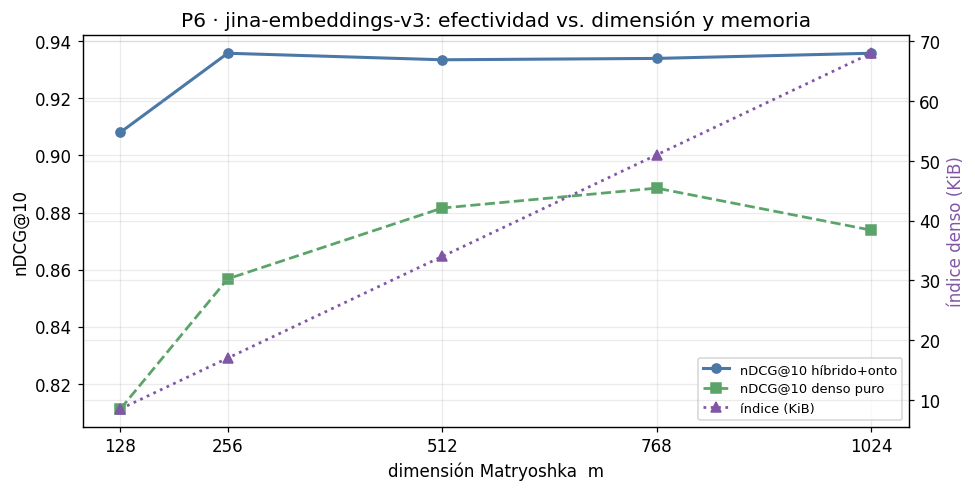

In [7]:
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(df_p6["dim"], df_p6["nDCG@10 híbrido+onto"], "o-", color="#4c78a8", lw=2, label="nDCG@10 híbrido+onto")
ax1.plot(df_p6["dim"], df_p6["nDCG@10 denso"], "s--", color="#5aa469", lw=1.8, label="nDCG@10 denso puro")
ax1.set_xlabel("dimensión Matryoshka  m"); ax1.set_ylabel("nDCG@10"); ax1.set_xticks(df_p6["dim"])
ax2 = ax1.twinx(); ax2.plot(df_p6["dim"], df_p6["índice_KiB"], "^:", color="#8156a7", lw=1.8, label="índice (KiB)")
ax2.set_ylabel("índice denso (KiB)", color="#8156a7")
l1,la1 = ax1.get_legend_handles_labels(); l2,la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, loc="lower right", fontsize=8.5)
ax1.set_title(f"P6 · {base.nombre}: efectividad vs. dimensión y memoria"); plt.tight_layout(); plt.show()

**Interpretación de resultados (P6).** Con MRL, truncar mantiene una **retención alta** de
nDCG@10 en la configuración desplegable, mientras el índice —lineal en `m`— se reduce en la
misma proporción. El **denso puro** es más sensible a `m`; el híbrido lo amortigua con la
señal léxica. A esta escala la latencia está dominada por la codificación de la consulta, así
que el beneficio inmediato de truncar es **memoria**.

## 5. P4 · Barrido de tamaño y solapamiento de fragmento

**Contexto y objetivo.** Partir cada documento en fragmentos de `tamaño` palabras con
`solapamiento` y recuperar a nivel de fragmento, agregando al documento por **máximo** (el
mejor fragmento representa al documento). Se evalúa la config Híbrido + ontología a dimensión
completa.

**Descripción técnica.** `tamaño = ∞` equivale al documento completo (línea base actual). Se
reporta también el promedio de fragmentos por documento, clave para interpretar el efecto.

In [8]:
def fragmentar(texto, tam, solapa_frac):
    "Parte en fragmentos de `tam` palabras con solapamiento (fracción). tam grande = 1 fragmento."
    palabras = texto.split()
    if tam >= len(palabras): return [texto]
    paso = max(1, int(round(tam*(1 - solapa_frac))))
    trozos = [" ".join(palabras[i:i+tam]) for i in range(0, len(palabras), paso) if palabras[i:i+tam]]
    return trozos or [texto]

full_enc = FullEncoder(cache)

def evaluar_chunking(tam, solapa):
    # construir corpus de fragmentos sobre el texto enriquecido (config híbrido+ontología)
    frag_ids, frag_doc, frag_txt = [], {}, []
    for d in docs:
        for j, ch in enumerate(fragmentar(d["texto_indexable"], tam, solapa)):
            fid = f"{d['id']}#{j}"; frag_ids.append(fid); frag_doc[fid] = d["id"]; frag_txt.append(ch)
    bm = BM25Index(cfg["bm25"]["k1"], cfg["bm25"]["b"]).indexar(frag_ids, frag_txt)
    dn = DenseIndex(full_enc).indexar(frag_ids, frag_txt)
    nds = []
    for c in con_gold:
        _, fus = rrf(bm.buscar(c["texto"]), dn.buscar(c["texto"]), cfg["fusion"]["k_rrf"])
        doc_score = {}
        for fid, s in fus.items():                       # agregación por máximo al documento
            did = frag_doc[fid]; doc_score[did] = max(doc_score.get(did, -1e9), s)
        rank = sorted(doc_score, key=lambda dd: (-doc_score[dd], dd))
        nds.append(ndcg(rank, qrels[c["id"]], 10))
    n_frag = len(frag_ids)
    return float(np.mean(nds)), n_frag/len(docs)

TAMS = [24, 40, 64, 128, 10**6]           # 10^6 = documento completo (baseline)
SOLAPES = [0.0, 0.25, 0.5]
filas = []
for tam in TAMS:
    fila = {"tamaño (palabras)": "doc completo" if tam >= 10**6 else tam}
    for so in SOLAPES:
        nd, fpd = evaluar_chunking(tam, so)
        fila[f"nDCG@10 (solapa {int(so*100)}%)"] = nd
        if so == 0.0: fila["frag/doc"] = round(fpd, 2)
    filas.append(fila)
df_p4 = pd.DataFrame(filas).set_index("tamaño (palabras)")
df_p4

,nDCG@10 (solapa 0%),frag/doc,nDCG@10 (solapa 25%),nDCG@10 (solapa 50%)
tamaño (palabras),,,,
24,0.868,4.710,0.827,0.833
40,0.834,2.940,0.827,0.865
64,0.894,2.120,0.890,0.873
128,0.934,1.240,0.913,0.930
doc completo,0.936,1.000,0.936,0.936


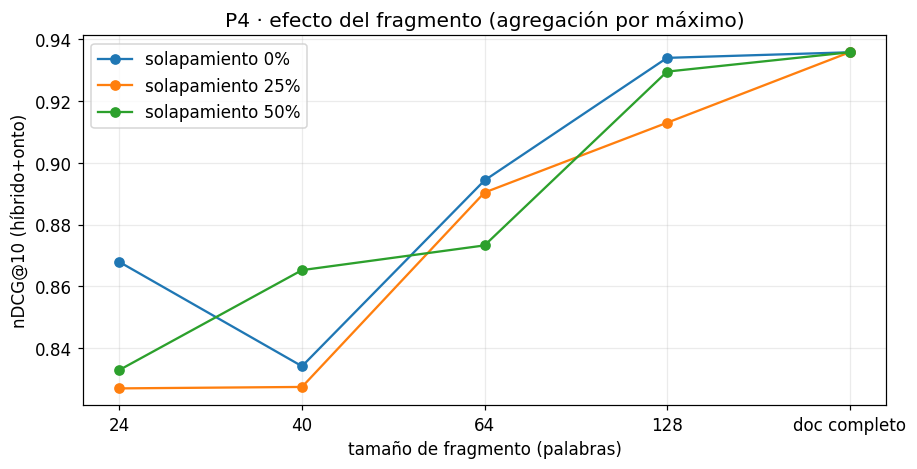

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
etq = [str(t) for t in df_p4.index]
for so in SOLAPES:
    col = f"nDCG@10 (solapa {int(so*100)}%)"
    ax.plot(etq, df_p4[col], "o-", label=f"solapamiento {int(so*100)}%")
ax.set_xlabel("tamaño de fragmento (palabras)"); ax.set_ylabel("nDCG@10 (híbrido+onto)")
ax.set_title("P4 · efecto del fragmento (agregación por máximo)"); ax.legend(); plt.tight_layout(); plt.show()

**Interpretación de resultados (P4).** A esta escala los reportes son cortos (≈ 65–180
palabras), de modo que con fragmentos grandes hay ~1 fragmento por documento y el resultado
coincide con la línea base. Con fragmentos pequeños el promedio de fragmentos por documento
sube, pero la agregación por máximo tiende a **no mejorar** (y puede perder contexto). La
conclusión honesta: **el chunking no aporta con documentos tan cortos**; su valor aparecerá
con documentos largos en la v2, para lo cual la maquinaria ya queda medida y lista.

## 6. Conclusión — configuración eficiente para despliegue local

**Interpretación y recomendación.**

- **Dimensión (P6):** truncar a la **menor `m` con retención ≥ 0.99** del nDCG@10 de
  referencia captura casi toda la calidad con una fracción de la memoria del índice. Es la
  palanca de eficiencia recomendada; ver la tabla de §4 para el `m` concreto.
- **Chunking (P4):** **mantener 1 documento = 1 unidad** en v1 (documentos cortos); reevaluar
  con documentos largos en v2.
- **Despliegue local sugerido:** Híbrido + ontología, embedding truncado a la `m` elegida,
  índice denso por coseno exacto (con 17–cientos de documentos no hace falta ANN; al crecer,
  migrar a HNSW). La latencia está dominada por la codificación de la consulta, no por la
  búsqueda.